# Comparaison des approches de recommandation

Ce notebook synthétise les résultats des deux approches testées :
- **Content-Based** (notebook 02) : similarité cosinus sur embeddings réduits par PCA
- **Collaborative Filtering** (notebook 03) : ALS sur matrice user-item sparse

Objectif : choisir l'approche à déployer dans l'Azure Function.

## 1. Comparaison quantitative — Precision@5

               Approche  Precision@5 Temps évaluation
          Content-Based        0.004           ~5 min
Collaborative Filtering        0.106         ~355 min


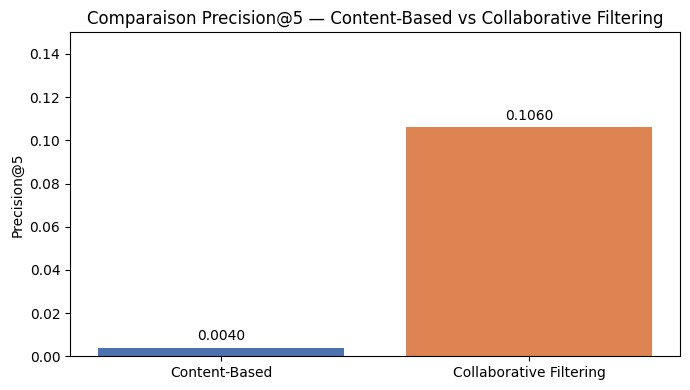

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Approche": ["Content-Based", "Collaborative Filtering"],
    "Precision@5": [0.0040, 0.1060],
    "Temps évaluation": ["~5 min", "~355 min"]
})

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results["Approche"], results["Precision@5"], color=["#4C72B0", "#DD8452"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylabel("Precision@5")
ax.set_title("Comparaison Precision@5 — Content-Based vs Collaborative Filtering")
ax.set_ylim(0, 0.15)
plt.tight_layout()
plt.show()

## 2. Comparaison qualitative

In [4]:
comparaison = pd.DataFrame({
    "Critères": [
        "Precision@5 (leave-one-out)",
        "Cold-start utilisateur",
        "Cold-start article",
        "Ajout de nouveaux articles",
        "Ajout de nouveaux utilisateurs",
        "Interprétabilité",
        "Temps d'entraînement",
        "Taille du modèle déployé"
    ],
    "Content-Based": [
        "0.0040",
        "Dès 1 clic",
        "Géré (embedding disponible)",
        "pca.transform() suffit",
        "Pas de réentraînement",
        "Bonne (similarité sémantique)",
        "Rapide",
        "Embeddings réduits (72,8 Mo)"
    ],
    "Collaborative Filtering": [
        "0.1060",
        "Historique minimum requis",
        "Non géré (jamais cliqué)",
        "Réentraînement complet",
        "Réentraînement complet",
        "Faible (facteurs latents)",
        "Long (ALS itératif)",
        "Matrices user/item factors"
    ]
})

comparaison

,Critères,Content-Based,Collaborative Filtering
0,Precision@5 (leave-one-out),0.0040,0.1060
1,Cold-start utilisateur,Dès 1 clic,Historique minimum requis
2,Cold-start article,Géré (embedding disponible),Non géré (jamais cliqué)
3,Ajout de nouveaux articles,pca.transform() suffit,Réentraînement complet
4,Ajout de nouveaux utilisateurs,Pas de réentraînement,Réentraînement complet
5,Interprétabilité,Bonne (similarité sémantique),Faible (facteurs latents)
6,Temps d'entraînement,Rapide,Long (ALS itératif)
7,Taille du modèle déployé,"Embeddings réduits (72,8 Mo)",Matrices user/item factors


* notes : 
    - Facteurs latents désigne les dimensions cachées que l'ALS apprend automatiquement pour représenter les utilisateurs et les articles. ces dimensions n'ont pas de nom ni de signification humaine directe. près entraînement, l'ALS représente chaque utilisateur par un vecteur de 50 valeurs numériques comme. On ne sait pas ce que représente la dimension 1, la dimension 2, etc... Le modèle les a inventées lui-même pour minimiser l'erreur de reconstruction de la matrice.
    - Dans le content-based, on comprend ce qu'on fait, on calcule la similarité entre des embeddings d'articles. Si deux articles sont recommandés, c'est parce qu'ils sont sémantiquement proches. C'est explicable.
    - Dans le CF avec ALS, si un article est recommandé, on peut juste dire "d'autres utilisateurs similaires l'ont aimé" — mais on ne peut pas expliquer pourquoi ces utilisateurs sont considérés similaires ni pourquoi cet article leur correspond. C'est une boîte noire.
    - pour la présentation, avec le CF on ne peut pas répondre précisément à la question "pourquoi on recommande cet article à cet utilisateru", c'est la limite d'interprétabilité.

## 3. Choix du modèle pour le déploiement MVP

Le **Collaborative Filtering (ALS)** est retenu pour le déploiement Azure Functions car :
- Score Precision@5 significativement supérieur (0.1060 vs 0.0040)
- Exploite efficacement les comportements collectifs des 322 897 utilisateurs

Limite connue : cold-start. En production, une architecture hybride serait recommandée :
- Utilisateur avec historique suffisant => CF
- Nouvel utilisateur (< seuil de clics) => Content-Based ou fallback articles populaires

Pour le MVP, on déploie le CF avec un fallback (=reco par défaut) sur les articles les plus populaires pour les nouveaux utilisateurs.

In [5]:
# Top 10 articles les plus populaires (fallback pour nouveaux utilisateurs)
import pandas as pd

DATA_DIR = "../news-portal-user-interactions-by-globocom"
clicks = pd.read_parquet(f"{DATA_DIR}/clicks_full.parquet")

top_articles = (
    clicks.groupby("click_article_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"click_article_id": "article_id", 0: "nb_clics"})
)

print("Top 10 articles les plus populaires (fallback) :")
print(top_articles.to_string(index=False))

Top 10 articles les plus populaires (fallback) :
 article_id  nb_clics
     160974     37213
     272143     28943
     336221     23851
     234698     23499
     123909     23122
     336223     21855
      96210     21577
     162655     21062
     183176     20303
     168623     19526


* notes :
    - l'article le plus populaire (160974) a été cliqué 37 213 fois sur ~3 millions de clics totaux, soit environ 1,2% de tous les clics. C'est une popularité significative, ce sera une bonne recommandation par défaut pour les nouveaux utilisateurs.

## 4. Taille du modèle CF déployé

In [6]:
import numpy as np

n_users = 322897
n_articles = 46033
n_factors = 50
bytes_per_float = 8  # float64

user_factors_size_mb = (n_users * n_factors * bytes_per_float) / 1e6
item_factors_size_mb = (n_articles * n_factors * bytes_per_float) / 1e6
total_cf_mb = user_factors_size_mb + item_factors_size_mb

print("=== Taille du modèle CF à déployer ===")
print(f"user_factors ({n_users} × {n_factors})  : {user_factors_size_mb:.1f} Mo")
print(f"item_factors ({n_articles} × {n_factors}) : {item_factors_size_mb:.1f} Mo")
print(f"Total CF                              : {total_cf_mb:.1f} Mo")
print()
print("=== Comparaison avec Content-Based ===")
cb_size_mb = 72.8
print(f"Embeddings réduits PCA (50 dims)      : {cb_size_mb} Mo")
print()
print(f"=> Le CF est {total_cf_mb / cb_size_mb:.1f}x plus lourd que le content-based")
print(f"=> Les deux restent dans les limites Azure gratuit (~1,5 Go)")

=== Taille du modèle CF à déployer ===
user_factors (322897 × 50)  : 129.2 Mo
item_factors (46033 × 50) : 18.4 Mo
Total CF                              : 147.6 Mo

=== Comparaison avec Content-Based ===
Embeddings réduits PCA (50 dims)      : 72.8 Mo

=> Le CF est 2.0x plus lourd que le content-based
=> Les deux restent dans les limites Azure gratuit (~1,5 Go)


In [7]:
comparaison.loc[comparaison["Critères"] == "Taille du modèle déployé", "Collaborative Filtering"] = "~147,6 Mo (user/item factors)"
comparaison

,Critères,Content-Based,Collaborative Filtering
0,Precision@5 (leave-one-out),0.0040,0.1060
1,Cold-start utilisateur,Dès 1 clic,Historique minimum requis
2,Cold-start article,Géré (embedding disponible),Non géré (jamais cliqué)
3,Ajout de nouveaux articles,pca.transform() suffit,Réentraînement complet
4,Ajout de nouveaux utilisateurs,Pas de réentraînement,Réentraînement complet
5,Interprétabilité,Bonne (similarité sémantique),Faible (facteurs latents)
6,Temps d'entraînement,Rapide,Long (ALS itératif)
7,Taille du modèle déployé,"Embeddings réduits (72,8 Mo)","~147,6 Mo (user/item factors)"


## 5. Notes pour la soutenance — Architecture Azure Function

### Authentification : pourquoi `auth_level=ANONYMOUS` ?

Notre Azure Function utilise `auth_level=ANONYMOUS` — n'importe qui peut l'appeler sans clé.

Il existe 3 niveaux d'authentification :

| Niveau | Description | Usage |
|---|---|---|
| `ANONYMOUS` | Pas de clé requise — accessible publiquement | MVP, démo |
| `FUNCTION` | Clé spécifique à la fonction requise | Production standard |
| `ADMIN` | Clé master de la Function App requise | Administration |

**Choix pour le MVP** : `ANONYMOUS` simplifie les appels depuis l'application Streamlit sans gérer de clés.

**En production** : on utiliserait `FUNCTION` pour éviter que n'importe qui consomme nos ressources Azure.

---

### Architecture serverless : pourquoi charger les artéfacts au démarrage du module ?

Les artifacts (modèle ALS, matrices, mappings) sont chargés **une seule fois** au démarrage, pas à chaque appel.

- **Si chargé à chaque appel** : lecture de ~119 Mo depuis le disque + désérialisation → plusieurs secondes de latence
- **Si chargé au démarrage** : artifacts en mémoire → chaque appel est quasi-instantané

C'est une bonne pratique standard pour les Azure Functions et les APIs en général.